<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 171 &middot; Capstone 12 &middot; Spearman Correlation</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Do Satisfied Customers Come Back?</div>
  <div style="font-size:15px;color:#fef3c7;max-width:800px;line-height:1.6">Two survey scales, both answered on a 1-to-7 Likert grid. The numbers look like measurements but they are labels of order, and that distinction decides which correlation you are entitled to compute.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
GOLD, DARK, BL, RD, GR, MUT = "#b45309", "#78350f", "#2563eb", "#dc2626", "#16a34a", "#94a3b8"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-satisfaction-and-loyalty.xlsx"
try:
    raw = pd.read_excel("../../data/" + fn, sheet_name="survey")
    qn  = pd.read_excel("../../data/" + fn, sheet_name="Questionnaire")
except FileNotFoundError:
    raw = pd.read_excel(BASE + fn, sheet_name="survey")
    qn  = pd.read_excel(BASE + fn, sheet_name="Questionnaire")
print("loaded", raw.shape[0], "responses")
raw.head()

loaded 187 responses


,respondent_id,satisfaction,repurchase_intent,tenure_years
0,Q4000,6,6.0,3.6
1,Q4001,1,1.0,3.7
2,Q4002,3,3.0,2.8
3,Q4003,7,6.0,3.8
4,Q4004,1,2.0,2.2


## Step 1 &middot; Goal and hypotheses
A customer survey asked two questions on 7-point scales: how satisfied people are, and how likely they are to buy again. The business question is whether satisfaction actually tracks loyalty, or whether happy customers leave anyway.

- **H&#8320; (null):** there is no monotonic association between satisfaction and repurchase intent.
- **H&#8321; (alternative):** there is one.
- **&#945; = 0.05.**

Note the word **monotonic** rather than *linear*. That is deliberate, and Step 4 explains why it is the honest formulation for this kind of data.

## Step 2 &middot; The instrument, and what its numbers mean

In [2]:
for _, r in qn.iterrows():
    print(f"  Q{r['no']}. {r['question']}")
    print(f"      type: {r['type']}")
    print(f"      options: {r['answer_options']}\n")

  Q1. Overall, how satisfied are you with our service?
      type: Ordinal (7-point Likert)
      options: 1 = Very dissatisfied ... 7 = Very satisfied

  Q2. How likely are you to buy from us again?
      type: Ordinal (7-point Likert)
      options: 1 = Very unlikely ... 7 = Very likely

  Q3. How long have you been a customer?
      type: Continuous (numeric entry)
      options: Years, to one decimal



**The critical detail.** Both key items are **7-point Likert scales**. The responses arrive as the numbers 1 to 7, and those numbers are ordered, so a 6 really does mean more satisfied than a 4. But nothing guarantees the **spacing** is equal: the psychological gap between "very dissatisfied" and "dissatisfied" need not equal the gap between "satisfied" and "very satisfied". The numbers are labels of order, not measured quantities, which makes these variables **ordinal** rather than continuous.

## Step 3 &middot; Prepare and clean
Valid Likert responses run 1 to 7, so anything outside that is a data-entry error. Drop duplicates, blanks, and out-of-range codes.

In [3]:
before = len(raw)
df = raw.drop_duplicates(); a_dup = len(df)
df = df.dropna(subset=["satisfaction","repurchase_intent"]); a_na = len(df)
bad = df[~(df.satisfaction.between(1,7) & df.repurchase_intent.between(1,7))]
df = df[df.satisfaction.between(1,7) & df.repurchase_intent.between(1,7)].copy()
df["satisfaction"] = df.satisfaction.astype(int)
df["repurchase_intent"] = df.repurchase_intent.astype(int)
print(f"start {before}  ->  dedup {a_dup} (-{before-a_dup})  ->  dropna {a_na} (-{a_dup-a_na})")
print("out-of-range Likert codes removed:", sorted(bad.satisfaction.tolist()))
print(f"clean analysis sample: n = {len(df)}")

start 187  ->  dedup 185 (-2)  ->  dropna 183 (-2)
out-of-range Likert codes removed: [9]
clean analysis sample: n = 182


## Step 4 &middot; Visualize: a grid, not a cloud
Ordinal data does not scatter like continuous data. With only 7 &#215; 7 possible answers, hundreds of respondents pile onto the same points, so an ordinary scatterplot would hide most of them. The right picture sizes each point by how many people gave that combination.

counts: satisfaction (rows) by repurchase intent (columns)

repurchase_intent  1   2   3  4   5   6   7
satisfaction                               
1                  6   7   0  0   0   0   0
2                  5  15   7  0   0   0   0
3                  2   9  12  5   0   1   0
4                  2   4   5  9  17   4   1
5                  0   1   3  3  10  12   3
6                  0   0   0  0   4   7  10
7                  0   0   0  0   3  11   4


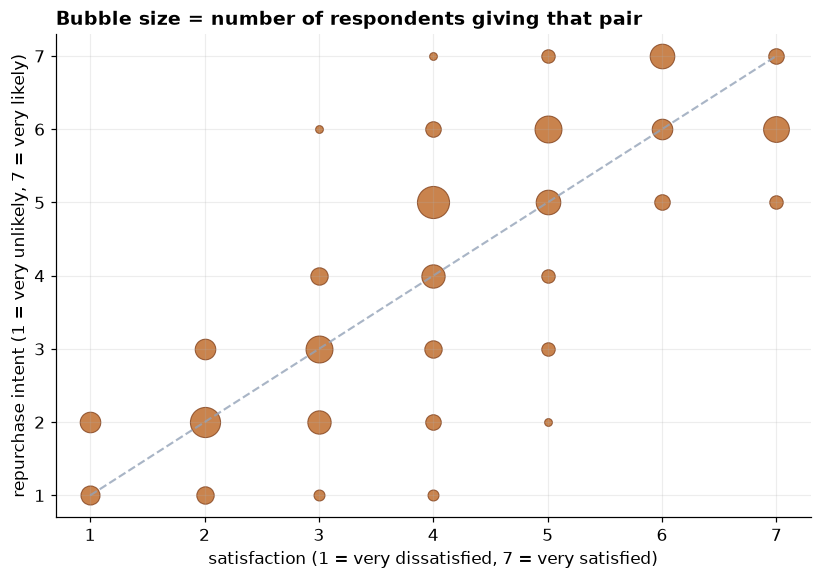

In [4]:
ct = pd.crosstab(df.satisfaction, df.repurchase_intent)
print("counts: satisfaction (rows) by repurchase intent (columns)\n")
print(ct.to_string())
fig, ax = plt.subplots(figsize=(7.6, 5.4))
for s in range(1,8):
    for l in range(1,8):
        c = ct.loc[s,l] if (s in ct.index and l in ct.columns) else 0
        if c: ax.scatter([s],[l], s=c*26, color=GOLD, alpha=0.72, edgecolor=DARK, linewidth=0.7)
ax.plot([1,7],[1,7], color=MUT, lw=1.4, ls="--", alpha=0.8)
ax.set_xticks(range(1,8)); ax.set_yticks(range(1,8))
ax.set_xlabel("satisfaction (1 = very dissatisfied, 7 = very satisfied)")
ax.set_ylabel("repurchase intent (1 = very unlikely, 7 = very likely)")
ax.set_title("Bubble size = number of respondents giving that pair")
plt.tight_layout(); plt.show()

**What the grid shows.** The mass runs from the bottom left to the top right: dissatisfied customers say they will not return, satisfied ones say they will. The relationship is clearly **monotonic**, meaning it goes one way without reversing. Whether it is *straight* is a harder question, and one we do not have to answer, because the method we are about to use does not need it.

## Step 5 &middot; Name the design and choose the measure
Two **ordinal** variables measured on the same respondents. Pearson's correlation assumes the variables are interval-scaled, that a one-unit step means the same thing everywhere on the scale. Likert responses do not guarantee that, so the appropriate measure is **Spearman's rank correlation**, which replaces the raw codes with their ranks and therefore uses only the ordering.

## Step 6 &middot; Run the test

In [5]:
s = df.satisfaction.values; l = df.repurchase_intent.values
rho, p_rho = stats.spearmanr(s, l)
tau, p_tau = stats.kendalltau(s, l)
r_p, p_p = stats.pearsonr(s, l)
n = len(df)
print(f"n = {n}")
print(f"Spearman's rho = {rho:.3f}   p = {p_rho:.2e}   <- the one we report")
print(f"Kendall's tau  = {tau:.3f}   p = {p_tau:.2e}")
print(f"Pearson's r    = {r_p:.3f}   (shown for comparison only)")

n = 182
Spearman's rho = 0.829   p = 2.84e-47   <- the one we report
Kendall's tau  = 0.710   p = 3.31e-35
Pearson's r    = 0.820   (shown for comparison only)


**Reading the result.** Satisfaction and repurchase intent are **strongly and monotonically associated** (&#961; = 0.83). Kendall's tau of 0.71 is lower, which is normal and not a disagreement: tau is built on a different scale, counting concordant against discordant pairs, and typically runs below rho for the same data. Notice that Pearson's r of 0.82 is very close to rho here, which raises a fair question: if the two agree, why insist on the rank method? Step 7 answers it.

## Step 7 &middot; Why the rank method, when Pearson gives almost the same number?
Because the two coefficients are not equally **trustworthy**, even when they agree. The numbers 1 to 7 are a convention. If the survey had been coded with different numbers that preserve the same order, the ordering of responses would be identical and nothing about what respondents said would change. Watch what happens to each coefficient.

In [6]:
codings = {
    "equal spacing        1,2,3,4,5,6,7":  {i:i for i in range(1,8)},
    "stretched at the top 1,2,3,4,6,9,13": dict(zip(range(1,8), [1,2,3,4,6,9,13])),
    "stretched at the base 1,5,8,10,11,12,13": dict(zip(range(1,8), [1,5,8,10,11,12,13])),
}
print(f"{'coding of the SAME ordered answers':44s} {'Pearson r':>10s} {'Spearman rho':>14s}")
print("-"*72)
for name, m in codings.items():
    sc = np.array([m[v] for v in s]); lc = np.array([m[v] for v in l])
    print(f"{name:44s} {stats.pearsonr(sc,lc).statistic:10.3f} {stats.spearmanr(sc,lc).statistic:14.3f}")

coding of the SAME ordered answers            Pearson r   Spearman rho
------------------------------------------------------------------------
equal spacing        1,2,3,4,5,6,7                0.820          0.829
stretched at the top 1,2,3,4,6,9,13               0.741          0.829
stretched at the base 1,5,8,10,11,12,13           0.788          0.829


**This is the whole argument.** All three codings preserve the order perfectly; only the arbitrary numbers change. **Pearson's r moves from 0.820 to 0.741 to 0.788**, while **Spearman's rho is 0.829 every time**. Pearson believes the numbers, so it inherits whatever arbitrary spacing the survey designer happened to choose. Spearman believes only the order, which is the only thing a Likert scale actually establishes. The rank method is the right tool here not because it gives a different answer, but because its answer does not depend on a decision nobody had grounds to make.

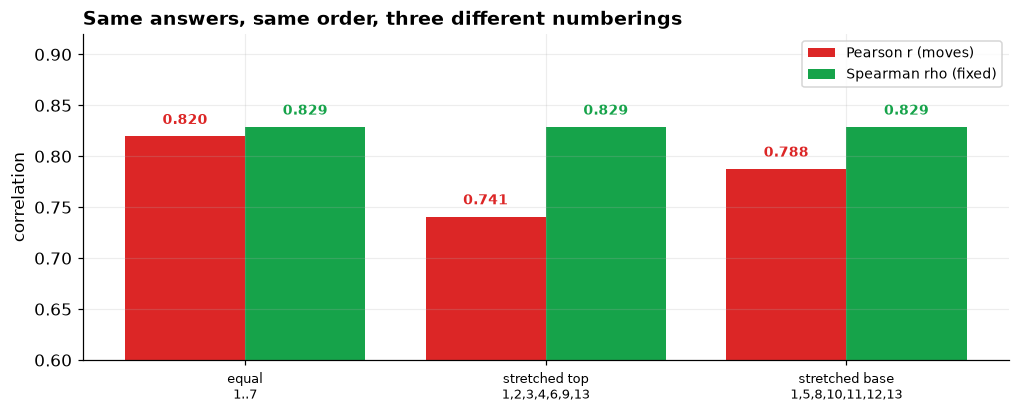

In [7]:
fig, ax = plt.subplots(figsize=(9.4, 3.9))
names = ["equal\n1..7", "stretched top\n1,2,3,4,6,9,13", "stretched base\n1,5,8,10,11,12,13"]
pears, spear = [], []
for m in codings.values():
    sc = np.array([m[v] for v in s]); lc = np.array([m[v] for v in l])
    pears.append(stats.pearsonr(sc,lc).statistic); spear.append(stats.spearmanr(sc,lc).statistic)
xx = np.arange(3)
ax.bar(xx-0.2, pears, 0.4, color=RD, label="Pearson r (moves)")
ax.bar(xx+0.2, spear, 0.4, color=GR, label="Spearman rho (fixed)")
for i,(pv,sv) in enumerate(zip(pears,spear)):
    ax.text(i-0.2, pv+0.012, f"{pv:.3f}", ha="center", fontsize=9, color=RD, fontweight="bold")
    ax.text(i+0.2, sv+0.012, f"{sv:.3f}", ha="center", fontsize=9, color=GR, fontweight="bold")
ax.set_xticks(xx); ax.set_xticklabels(names, fontsize=8.5)
ax.set_ylim(0.6, 0.92); ax.set_ylabel("correlation")
ax.set_title("Same answers, same order, three different numberings")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

**The picture of the argument.** Three red bars at three different heights, three green bars at one height. Nothing about the respondents changed between the groups; only the numbers assigned to their answers did.

## Step 8 &middot; Ties, and why they are unavoidable here
With only seven possible answers and 182 respondents, huge numbers of people share the same rank. Rank methods handle this by assigning the average rank within each tied block, which is exactly what `scipy` does.

In [8]:
print("respondents per satisfaction level:")
print(df.satisfaction.value_counts().sort_index().to_string())
print(f"\n{n} respondents spread over just 7 levels -> heavy ties by construction")
print("scipy assigns midranks within tied blocks, which is the standard treatment.")
print(f"\nKendall's tau-b ({tau:.3f}) applies an explicit tie correction,")
print("which is why it is sometimes preferred for short scales with many ties.")

respondents per satisfaction level:
satisfaction
1    13
2    27
3    29
4    42
5    32
6    21
7    18

182 respondents spread over just 7 levels -> heavy ties by construction
scipy assigns midranks within tied blocks, which is the standard treatment.

Kendall's tau-b (0.710) applies an explicit tie correction,
which is why it is sometimes preferred for short scales with many ties.


**Why this matters.** Ties are not a defect in the data; they are the inevitable consequence of a 7-point scale. Rank methods are built to cope with them. It is worth knowing that Kendall's tau-b carries an explicit correction for ties and is often the more conservative choice on short scales, though rho and tau lead to the same conclusion here.

## Step 9 &middot; Interpret in plain language
Satisfaction and stated repurchase intent move together strongly (&#961; = 0.83). Customers who report being satisfied overwhelmingly say they will buy again, and dissatisfied customers say they will not. For the business the finding supports treating satisfaction as a leading indicator of retention, with the significant caveat in the next step about what was actually measured.

## Step 10 &middot; Ethics, bias, and limits
- **Both variables are stated intentions, not behaviour.** We measured what customers *say* they will do. The gap between stated intent and actual repurchase is well documented and often large. This analysis establishes that two survey answers agree with each other, which is weaker than establishing that satisfaction predicts revenue.
- **Common-method bias inflates the association.** Both answers came from the same person, on the same form, moments apart. Someone in a good mood marks both scales high. Part of &#961; = 0.83 is very likely the respondent's general disposition rather than a genuine satisfaction-to-loyalty link, which is exactly why linking survey answers to *observed* repurchase would be the stronger study.
- **Who answered?** Survey respondents are self-selected, and people with strong feelings answer more readily. The middle of the distribution is probably under-represented.
- **Do not average Likert scores casually.** The same reasoning that sent us to Spearman applies to reporting "average satisfaction of 4.6": that number assumes the equal spacing the scale does not provide. Medians and full response distributions are the safer summaries.

---
**From analysis to report.** The notebook carries the evidence: the instrument, the cleaning, the response grid, the rank correlations, the recoding demonstration, and the ties discussion. The written reports turn it into a recommendation a customer-experience lead can act on and a technical account a fellow statistician can audit. Automate the evidence; author the argument.